# 멋진 챗봇 만들기


| Step | 내용 |
|------|------|
| Step 1 | 데이터 다운로드 & 로드 |
| Step 2 | 데이터 정제 (`preprocess_sentence`) |
| Step 3 | MeCab 토큰화 (`build_corpus`) |
| Step 4 | Augmentation (한국어 Word2Vec Lexical Substitution, 3배) |
| Step 5 | 데이터 벡터화 (`enc_train`, `dec_train`) |
| Step 6 | Transformer 훈련 |
| Step 7 | 성능 측정 (BLEU + Attention Map) |

## 환경설정

In [1]:
# Cell 1

# 필요 패키지 설치
import subprocess, sys

pkgs = ['python-mecab-ko', 'gensim', 'nltk']
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import nltk
nltk.download('punkt', quiet=True)
print('설치 완료')

설치 완료


In [2]:
# Cell 2

%matplotlib inline
import os, re, math, random, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from mecab import MeCab                          # python-mecab-ko (Mac ARM64 호환)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

warnings.filterwarnings('ignore')

# 시드 고정
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# 디바이스
if torch.cuda.is_available():        device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                device = torch.device('cpu')

# MeCab 초기화
mecab = MeCab()
print(f'Device: {device}')
print(f'MeCab test: {mecab.morphs("오늘 날씨가 어때요?")}')
print('Sempre')

Device: mps
MeCab test: ['오늘', '날씨', '가', '어때요', '?']
Sempre


In [3]:
# Cell 3

# ─── 하이퍼파라미터 ───────────────────────────────────────────────
MAX_LEN      = 25      # 형태소 기준 최대 길이
BATCH_SIZE   = 64
EPOCHS       = 10

# Transformer
N_LAYERS     = 2
D_MODEL      = 256
N_HEADS      = 8
D_FF         = 512
DROPOUT      = 0.2
WARMUP_STEPS = 1000

# 경로
DATA_PATH    = 'ChatbotData.csv'
KO_BIN_PATH  = 'ko_extracted/ko.bin'

print('하이퍼파라미터 설정 완료')
print(f'  MAX_LEN={MAX_LEN}, BATCH={BATCH_SIZE}, EPOCHS={EPOCHS}')
print(f'  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, d_ff={D_FF}')
print('Sempre')

하이퍼파라미터 설정 완료
  MAX_LEN=25, BATCH=64, EPOCHS=10
  n_layers=2, d_model=256, n_heads=8, d_ff=512
Sempre


## Step 1. 데이터 로드

In [4]:
# Cell 4

# CSV 로드 → questions, answers 분리
df = pd.read_csv(DATA_PATH)
print(f'데이터 크기: {df.shape}')
print(df.head())

questions = df['Q'].astype(str).tolist()
answers   = df['A'].astype(str).tolist()

print(f'\nquestions 수: {len(questions)}')
print(f'answers   수: {len(answers)}')
print(f'\n예시 Q: {questions[0]}')
print(f'예시 A: {answers[0]}')
print('Sempre')

데이터 크기: (11823, 3)
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0

questions 수: 11823
answers   수: 11823

예시 Q: 12시 땡!
예시 A: 하루가 또 가네요.
Sempre


## Step 2. 데이터 정제 (`preprocess_sentence`)

In [5]:
# Cell 5

def preprocess_sentence(sentence):
    """
    1. 영문자 소문자 변환
    2. 한글, 영문자, 숫자, 주요 특수문자 외 제거 (정규식)
    """
    sentence = sentence.lower()                               # 소문자 변환
    sentence = re.sub(r"[^가-힣a-z0-9.,!?'\s]", " ", sentence) # 허용 문자 외 제거
    sentence = re.sub(r'\s+', ' ', sentence).strip()          # 중복 공백 제거
    return sentence


# 테스트
test_cases = [
    '오늘 날씨가 어때요??^^',
    'Hello World! 안녕하세요~',
    '3박4일 놀러가고 싶다!!!'
]
for s in test_cases:
    print(f'원문 : {s}')
    print(f'정제 : {preprocess_sentence(s)}')
    print()
print('Sempre')

원문 : 오늘 날씨가 어때요??^^
정제 : 오늘 날씨가 어때요??

원문 : Hello World! 안녕하세요~
정제 : hello world! 안녕하세요

원문 : 3박4일 놀러가고 싶다!!!
정제 : 3박4일 놀러가고 싶다!!!

Sempre


## Step 3. 데이터 토큰화 (`build_corpus`)

- `preprocess_sentence()`로 정제 후 MeCab `morphs()` 로 토큰화
- `MAX_LEN` 초과 문장 제거
- 소스/타겟 각각 독립적으로 중복 제거 (쌍 유지)

In [6]:
# Cell 6

def build_corpus(src_data, tgt_data, tokenize_fn, max_len=25):
    """
    Parameters
    ----------
    src_data    : list[str] — 소스 문장 (질문)
    tgt_data    : list[str] — 타겟 문장 (답변)
    tokenize_fn : callable  — 토큰화 함수 (mecab.morphs)
    max_len     : int       — 최대 토큰 수

    Returns
    -------
    src_corpus, tgt_corpus : list[list[str]]
    """
    src_corpus, tgt_corpus = [], []
    seen_src, seen_tgt     = set(), set()   # 소스/타겟 각각 중복 추적

    for src, tgt in zip(src_data, tgt_data):
        src_clean = preprocess_sentence(src)
        tgt_clean = preprocess_sentence(tgt)

        src_tokens = tokenize_fn(src_clean)
        tgt_tokens = tokenize_fn(tgt_clean)

        # 길이 필터
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue

        # 중복 필터 (소스는 소스대로, 타겟은 타겟대로)
        if src_clean in seen_src or tgt_clean in seen_tgt:
            continue

        seen_src.add(src_clean)
        seen_tgt.add(tgt_clean)

        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    return src_corpus, tgt_corpus


# 실행
que_corpus, ans_corpus = build_corpus(
    questions, answers, mecab.morphs, max_len=MAX_LEN
)

print(f'원본 데이터  : {len(questions):,}개')
print(f'정제 후 데이터: {len(que_corpus):,}개')
print(f'\n예시 Q 토큰: {que_corpus[0]}')
print(f'예시 A 토큰: {ans_corpus[0]}')
print('Sempre')

원본 데이터  : 11,823개
정제 후 데이터: 7,708개

예시 Q 토큰: ['12', '시', '땡', '!']
예시 A 토큰: ['하루', '가', '또', '가', '네요', '.']
Sempre


## Step 4. Augmentation (한국어 Word2Vec Lexical Substitution)

- `Kyubyong/wordvectors` Korean (w) 모델 (`ko.bin`) 사용
- `lexical_sub()`: 문장의 랜덤 단어를 유의어로 교체
- 최종 데이터 = 원본(1x) + Q증강/A원본(+1x) + Q원본/A증강(+1x) = **3배**

In [7]:
# Cell 7

# ─── 한국어 Word2Vec 로드 ─────────────────────────────────────────
# ko.bin은 구버전 gensim 형식 → pickle로 직접 로드
with open(KO_BIN_PATH, 'rb') as f:
    _ko_model = pickle.load(f, encoding='latin1')

wv_vocab = _ko_model.vocab        # {word: Vocab 객체}
wv_syn0  = _ko_model.syn0         # [vocab_size, 200] 벡터 행렬
id2word  = {v.index: k for k, v in wv_vocab.items()}

# 코사인 유사도 계산을 위한 정규화 벡터 미리 계산
wv_norms      = np.linalg.norm(wv_syn0, axis=1, keepdims=True)
wv_normalized = wv_syn0 / (wv_norms + 1e-8)

print(f'한국어 Word2Vec 로드 완료')
print(f'  vocab 크기: {len(wv_vocab):,}')
print(f'  벡터 차원 : {wv_syn0.shape[1]}')
print(f'  "오늘" 유사어 테스트:')

# 유사어 테스트
def most_similar(word, topn=5):
    if word not in wv_vocab:
        return []
    idx      = wv_vocab[word].index
    vec_norm = wv_normalized[idx]
    sims     = wv_normalized @ vec_norm          # [vocab_size]
    top_ids  = sims.argsort()[::-1][1:topn+1]   # 자기 자신 제외
    return [(id2word[i], float(sims[i])) for i in top_ids]

print(most_similar('오늘'))
print(most_similar('친구'))
print('Sempre')

한국어 Word2Vec 로드 완료
  vocab 크기: 30,185
  벡터 차원 : 200
  "오늘" 유사어 테스트:
[('아침', 0.5024495124816895), ('저물', 0.455463707447052), ('내일', 0.44492706656455994), ('지금', 0.44039565324783325), ('새벽', 0.4366644620895386)]
[('연인', 0.758503258228302), ('애인', 0.7489752769470215), ('엄마', 0.7044110894203186), ('동료', 0.6891161799430847), ('언니', 0.6841583251953125)]
Sempre


In [8]:
# Cell 8

# ─── Lexical Substitution 함수 ────────────────────────────────────
def lexical_sub(tokens):
    """
    tokens 리스트에서 Word2Vec vocab에 있는 단어 중 하나를
    유의어로 교체하여 반환. vocab에 없으면 원본 반환.
    """
    valid_tokens = [t for t in tokens if t in wv_vocab]
    if not valid_tokens:
        return tokens[:]

    selected_tok = random.choice(valid_tokens)
    similars     = most_similar(selected_tok, topn=5)

    if not similars:
        return tokens[:]

    substitute = similars[0][0]  # 가장 유사한 단어
    return [substitute if t == selected_tok else t for t in tokens]


# 테스트
sample_q = que_corpus[2]
print(f'원문  : {sample_q}')
print(f'증강  : {lexical_sub(sample_q)}')
print('Sempre')

원문  : ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
증강  : ['3', '박', '4', '월과', '놀', '러', '가', '고', '싶', '다']
Sempre


In [9]:
# Cell 9

# ─── Augmentation 적용 (3배 증강) ────────────────────────────────
print('Q Augmentation 중...')
aug_que_corpus = [lexical_sub(tokens) for tokens in tqdm(que_corpus)]

print('A Augmentation 중...')
aug_ans_corpus = [lexical_sub(tokens) for tokens in tqdm(ans_corpus)]

# 최종 데이터 구성 (3배)
#  Part1: 원본 Q + 원본 A
#  Part2: 증강 Q + 원본 A  ← Q만 바꿔서 같은 A로 학습
#  Part3: 원본 Q + 증강 A  ← 같은 Q에 다른 A 표현으로 학습
final_que = que_corpus     + aug_que_corpus + que_corpus
final_ans = ans_corpus     + ans_corpus     + aug_ans_corpus

print(f'\n원본 크기    : {len(que_corpus):,}')
print(f'Augmentation 후: {len(final_que):,} ({len(final_que)/len(que_corpus):.1f}배)')
print('Sempre')

Q Augmentation 중...


100%|██████████| 7708/7708 [00:11<00:00, 643.72it/s]


A Augmentation 중...


100%|██████████| 7708/7708 [00:12<00:00, 640.17it/s]


원본 크기    : 7,708
Augmentation 후: 23,124 (3.0배)
Sempre


## Step 5. 데이터 벡터화

1. `ans_corpus`에 `<start>`, `<end>` 토큰 추가
2. `que_corpus + ans_corpus` 합쳐서 공유 단어사전 구축
3. 정수 인코딩 → `enc_train`, `dec_train`

In [10]:
# Cell 10

# ─── <start> / <end> 토큰 추가 ───────────────────────────────────
final_ans_with_tokens = [
    ['<start>'] + tokens + ['<end>'] for tokens in final_ans
]

print('예시 ans_corpus (토큰 추가 전):', final_ans[0])
print('예시 ans_corpus (토큰 추가 후):', final_ans_with_tokens[0])
print('Sempre')

예시 ans_corpus (토큰 추가 전): ['하루', '가', '또', '가', '네요', '.']
예시 ans_corpus (토큰 추가 후): ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']
Sempre


In [11]:
# Cell 11

# ─── 공유 단어사전 구축 ───────────────────────────────────────────
class Vocabulary:
    """Q와 A를 동일 언어(한국어)로 처리 → 단어사전 공유"""
    PAD   = '<pad>'
    START = '<start>'
    END   = '<end>'
    UNK   = '<unk>'

    def __init__(self):
        self.word2idx = {
            self.PAD: 0, self.START: 1, self.END: 2, self.UNK: 3
        }
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self._next    = 4

    def build(self, corpus_list):
        """corpus_list: list of token lists"""
        for tokens in corpus_list:
            for token in tokens:
                if token not in self.word2idx:
                    self.word2idx[token] = self._next
                    self.idx2word[self._next] = token
                    self._next += 1

    def encode(self, tokens, max_len):
        ids = [self.word2idx.get(t, 3) for t in tokens]
        ids = ids[:max_len]
        ids += [0] * (max_len - len(ids))
        return ids

    def __len__(self):
        return len(self.word2idx)


# que + ans 결합하여 단어사전 구축
vocab = Vocabulary()
vocab.build(final_que + final_ans_with_tokens)

VOCAB_SIZE = len(vocab)
print(f'단어사전 크기: {VOCAB_SIZE:,}')
print(f'  <pad>={vocab.word2idx["<pad>"]}, '
      f'<start>={vocab.word2idx["<start>"]}, '
      f'<end>={vocab.word2idx["<end>"]}')
print('Sempre')

단어사전 크기: 7,189
  <pad>=0, <start>=1, <end>=2
Sempre


In [12]:
# Cell 12

# ─── 정수 인코딩 → enc_train, dec_train ──────────────────────────
DEC_MAX = MAX_LEN + 2   # <start> + tokens + <end>

enc_train = [vocab.encode(tokens, MAX_LEN) for tokens in final_que]
dec_train = [vocab.encode(tokens, DEC_MAX) for tokens in final_ans_with_tokens]

enc_train = np.array(enc_train, dtype=np.int64)
dec_train = np.array(dec_train, dtype=np.int64)

print(f'enc_train shape: {enc_train.shape}  (N, MAX_LEN={MAX_LEN})')
print(f'dec_train shape: {dec_train.shape}  (N, DEC_MAX={DEC_MAX})')
print(f'\nenc_train 샘플: {enc_train[0]}')
print(f'dec_train 샘플: {dec_train[0]}')
print('Sempre')

enc_train shape: (23124, 25)  (N, MAX_LEN=25)
dec_train shape: (23124, 27)  (N, DEC_MAX=27)

enc_train 샘플: [4 5 6 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
dec_train 샘플: [   1  477   19  499   19 1551   81    2    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0]
Sempre


In [13]:
# Cell 13

# ─── Train / Val / Test 분할 ─────────────────────────────────────
from sklearn.model_selection import train_test_split

enc_tr, enc_tmp, dec_tr, dec_tmp = train_test_split(
    enc_train, dec_train, test_size=0.2, random_state=SEED
)
enc_val, enc_test, dec_val, dec_test = train_test_split(
    enc_tmp, dec_tmp, test_size=0.5, random_state=SEED
)

print(f'Train: {len(enc_tr):,}')
print(f'Val  : {len(enc_val):,}')
print(f'Test : {len(enc_test):,}')
print('Sempre')

Train: 18,499
Val  : 2,312
Test : 2,313
Sempre


In [14]:
# Cell 14

# ─── Dataset & DataLoader ────────────────────────────────────────
class ChatbotDataset(Dataset):
    def __init__(self, enc, dec):
        self.enc = torch.tensor(enc, dtype=torch.long)
        self.dec = torch.tensor(dec, dtype=torch.long)

    def __len__(self):
        return len(self.enc)

    def __getitem__(self, idx):
        return self.enc[idx], self.dec[idx]


train_loader = DataLoader(ChatbotDataset(enc_tr,   dec_tr),   batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(ChatbotDataset(enc_val,  dec_val),  batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(ChatbotDataset(enc_test, dec_test), batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')
print('Sempre')

Train batches: 289
Val   batches: 37
Test  batches: 37
Sempre


## Step 6. Transformer 모델 훈련

In [15]:
# Cell 15

# ─── Positional Encoding ─────────────────────────────────────────
def positional_encoding(max_len, d_model):
    PE = np.zeros((max_len, d_model))
    for pos in range(max_len):
        for i in range(0, d_model, 2):
            PE[pos, i]     = np.sin(pos / np.power(10000, (2*i) / d_model))
            if i+1 < d_model:
                PE[pos, i+1] = np.cos(pos / np.power(10000, (2*i) / d_model))
    return PE

print('Sempre')

Sempre


In [16]:
# Cell 16

# ─── 마스크 생성 ──────────────────────────────────────────────────
def generate_padding_mask(seq):
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size):
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src, tgt):
    enc_mask      = generate_padding_mask(src)
    dec_enc_mask  = generate_padding_mask(src)
    dec_lookahead = generate_lookahead_mask(tgt.shape[1]).unsqueeze(0).unsqueeze(1).to(device)
    dec_pad       = generate_padding_mask(tgt).to(device)
    dec_mask      = torch.max(dec_pad, dec_lookahead)
    return enc_mask, dec_enc_mask, dec_mask

print('Sempre')

Sempre


In [17]:
# Cell 17

# ─── Multi-Head Attention ────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.depth     = d_model // num_heads
        self.d_model   = d_model
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.fc  = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        b, s, _ = x.size()
        return x.view(b, s, self.num_heads, self.depth).permute(0, 2, 1, 3)

    def combine_heads(self, x):
        b, h, s, d = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(b, s, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ = self.split_heads(self.W_q(Q))
        WK = self.split_heads(self.W_k(K))
        WV = self.split_heads(self.W_v(V))
        scores = torch.matmul(WQ, WK.transpose(-1, -2)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores + (mask * -1e9)
        attn   = F.softmax(scores, dim=-1)
        out    = self.fc(self.combine_heads(torch.matmul(attn, WV)))
        return out, attn

print('Sempre')

Sempre


In [18]:
# Cell 18

# ─── FFN / EncoderLayer / DecoderLayer ───────────────────────────
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1  = nn.Linear(d_model, d_ff)
        self.fc2  = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn       = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1     = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2     = nn.LayerNorm(d_model, eps=1e-6)
        self.drop      = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out, attn = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        x = residual + self.drop(out)
        residual = x
        x = residual + self.drop(self.ffn(self.norm2(x)))
        return x, attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn    = MultiHeadAttention(d_model, n_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn          = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1        = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2        = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3        = nn.LayerNorm(d_model, eps=1e-6)
        self.drop         = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        residual = x
        out, dec_attn = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), dec_mask)
        x = residual + self.drop(out)
        residual = x
        out, dec_enc_attn = self.enc_dec_attn(self.norm2(x), enc_out, enc_out, dec_enc_mask)
        x = residual + self.drop(out)
        residual = x
        x = residual + self.drop(self.ffn(self.norm3(x)))
        return x, dec_attn, dec_enc_attn

print('Sempre')

Sempre


In [19]:
# Cell 19

# ─── Encoder / Decoder ───────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        dec_attns, dec_enc_attns = [], []
        for layer in self.layers:
            x, dec_attn, dec_enc_attn = layer(x, enc_out, dec_enc_mask, dec_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return x, dec_attns, dec_enc_attns

print('Sempre')

Sempre


In [20]:
# Cell 20

# ─── Transformer 모델 ────────────────────────────────────────────
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 vocab_size, pos_len, dropout=0.2,
                 shared_fc=True, shared_emb=True):
        super().__init__()
        self.d_model   = float(d_model)
        self.shared_fc = shared_fc

        # Q와 A 동일 언어 → 임베딩 공유
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=0)

        pe = positional_encoding(pos_len, d_model)
        self.register_buffer('pos_enc', torch.tensor(pe, dtype=torch.float32))

        self.dropout = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc_out  = nn.Linear(d_model, vocab_size)

        if shared_fc:
            self.fc_out.weight = self.emb.weight   # 가중치 공유

    def embed(self, x):
        seq_len = x.size(1)
        out = self.emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_enc[:seq_len].unsqueeze(0)
        return self.dropout(out)

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_out, enc_attns = self.encoder(self.embed(enc_in), enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(
            self.embed(dec_in), enc_out, dec_enc_mask, dec_mask
        )
        logits = self.fc_out(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print('Sempre')

Sempre


In [21]:
# Cell 21

# ─── 모델 인스턴스 ───────────────────────────────────────────────
transformer = Transformer(
    n_layers   = N_LAYERS,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    d_ff       = D_FF,
    vocab_size = VOCAB_SIZE,
    pos_len    = DEC_MAX + 5,
    dropout    = DROPOUT,
    shared_fc  = True,
    shared_emb = True
).to(device)

total_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f'총 파라미터: {total_params:,}  ({total_params/1e6:.2f}M)')

# ─── Hyperparameters 요약 ────────────────────────────────────────
print(f'\n[Hyperparameters]')
print(f'  n_layers : {N_LAYERS}')
print(f'  d_model  : {D_MODEL}')
print(f'  n_heads  : {N_HEADS}')
print(f'  d_ff     : {D_FF}')
print(f'  dropout  : {DROPOUT}')
print(f'  vocab    : {VOCAB_SIZE}')
print('Sempre')

총 파라미터: 4,483,349  (4.48M)

[Hyperparameters]
  n_layers : 2
  d_model  : 256
  n_heads  : 8
  d_ff     : 512
  dropout  : 0.2
  vocab    : 7189
Sempre


In [22]:
# Cell 22

# ─── Loss / Accuracy / LR Scheduler ─────────────────────────────
def loss_function(real, pred):
    real = real.to(device)
    pred = pred.to(device)
    loss = F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)),
        real.contiguous().view(-1),
        reduction='none'
    ).view(real.size())
    mask = (real != 0).float()
    return (loss * mask).sum() / mask.sum()


def calc_accuracy(pred, real):
    mask    = (real != 0)
    correct = (pred.argmax(dim=-1) == real) & mask
    return correct.sum().item() / mask.sum().item()


class LRScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model      = d_model
        self.warmup_steps = warmup_steps
    def get_lr(self, step):
        step = max(step, 1)
        return (self.d_model ** -0.5) * min(step ** -0.5, step * self.warmup_steps ** -1.5)


lr_scheduler = LRScheduler(D_MODEL, warmup_steps=WARMUP_STEPS)
optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=lr_scheduler.get_lr(1),
    betas=(0.9, 0.98), eps=1e-9
)
print('Sempre')

Sempre


In [23]:
# Cell 23

# ─── Train / Eval Step ───────────────────────────────────────────
def train_step(src, tgt, model, optimizer, step):
    model.train()
    optimizer.zero_grad()

    tgt_in = tgt[:, :-1]    # decoder input:  <start> ~ 마지막 전
    gold   = tgt[:, 1:]     # label        :  첫 토큰 다음 ~ <end>

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
    src, tgt_in = src.to(device), tgt_in.to(device)
    enc_mask    = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)

    pred, *_ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, pred)
    acc  = calc_accuracy(pred, gold.to(device))

    loss.backward()
    # Noam LR 업데이트
    for pg in optimizer.param_groups:
        pg['lr'] = lr_scheduler.get_lr(step)
    optimizer.step()
    return loss.item(), acc


@torch.no_grad()
def eval_step(loader, model):
    model.eval()
    total_loss, total_acc, n = 0., 0., 0
    for src, tgt in loader:
        tgt_in = tgt[:, :-1]
        gold   = tgt[:, 1:]
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
        src, tgt_in = src.to(device), tgt_in.to(device)
        enc_mask     = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)
        pred, *_ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        total_loss += loss_function(gold, pred).item()
        total_acc  += calc_accuracy(pred, gold.to(device))
        n += 1
    return total_loss / n, total_acc / n

print('Sempre')

Sempre


In [24]:
# Cell 24

# ─── 훈련 루프 ───────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [],
           'val_loss'  : [], 'val_acc'  : []}
global_step = 0

for epoch in range(1, EPOCHS + 1):
    epoch_loss, epoch_acc, n = 0., 0., 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')

    for src, tgt in pbar:
        global_step += 1
        loss, acc = train_step(src, tgt, transformer, optimizer, global_step)
        epoch_loss += loss; epoch_acc += acc; n += 1
        pbar.set_postfix({'loss': f'{loss:.4f}', 'acc': f'{acc:.4f}'})

    val_loss, val_acc = eval_step(val_loader, transformer)

    history['train_loss'].append(epoch_loss / n)
    history['train_acc'].append(epoch_acc  / n)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'[Epoch {epoch:2d}] '
          f'train_loss={epoch_loss/n:.4f} train_acc={epoch_acc/n:.4f} '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

torch.save(transformer.state_dict(), 'chatbot_transformer.pt')
print('\n모델 저장: chatbot_transformer.pt')
print('Sempre')

Epoch 1/10: 100%|██████████| 289/289 [00:09<00:00, 29.30it/s, loss=1241.3041, acc=0.2177]


[Epoch  1] train_loss=2679.7008 train_acc=0.1143 val_loss=1119.8095 val_acc=0.2726


Epoch 2/10: 100%|██████████| 289/289 [00:07<00:00, 38.47it/s, loss=578.1517, acc=0.2561] 


[Epoch  2] train_loss=893.8294 train_acc=0.2328 val_loss=540.0751 val_acc=0.2845


Epoch 3/10: 100%|██████████| 289/289 [00:07<00:00, 38.74it/s, loss=412.9448, acc=0.2525]


...

[Epoch  8] train_loss=80.5007 train_acc=0.2639 val_loss=40.7602 val_acc=0.2977


Epoch 9/10: 100%|██████████| 289/289 [00:07<00:00, 38.24it/s, loss=66.3480, acc=0.2699]


[Epoch  9] train_loss=69.0551 train_acc=0.2637 val_loss=33.7411 val_acc=0.3208


Epoch 10/10: 100%|██████████| 289/289 [00:07<00:00, 38.18it/s, loss=60.6362, acc=0.2769]


[Epoch 10] train_loss=60.5116 train_acc=0.2645 val_loss=29.4263 val_acc=0.3127

모델 저장: chatbot_transformer.pt
Sempre


Train Loss: 60.5116 | Train Acc: 0.2645
Val   Loss: 29.4263   | Val   Acc: 0.3127
Test  Loss: 28.8265                 | Test  Acc: 0.3204


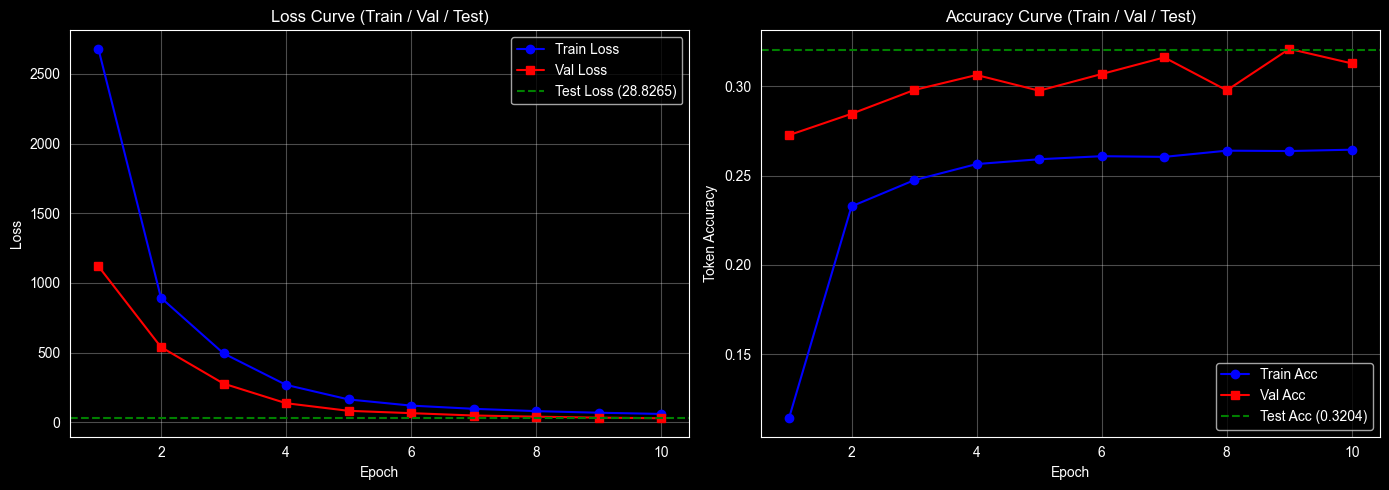

슝=3


In [25]:
# Cell 25

# ─── Test 평가 (훈련 완료 후 1회) ───────────────────────────────
test_loss, test_acc = eval_step(test_loader, transformer)
print(f'Train Loss: {history["train_loss"][-1]:.4f} | Train Acc: {history["train_acc"][-1]:.4f}')
print(f'Val   Loss: {history["val_loss"][-1]:.4f}   | Val   Acc: {history["val_acc"][-1]:.4f}')
print(f'Test  Loss: {test_loss:.4f}                 | Test  Acc: {test_acc:.4f}')

# ─── 학습 커브 (train / val / test) ──────────────────────────────
# 루브릭 요구: train loss/acc, val loss/acc, test loss/acc
# test는 에포크별로 측정하지 않으므로 최종값을 수평 점선으로 표시
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 커브
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'r-s', label='Val Loss')
axes[0].axhline(y=test_loss, color='g', linestyle='--',
                label=f'Test Loss ({test_loss:.4f})')
axes[0].set_title('Loss Curve (Train / Val / Test)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy 커브
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'],   'r-s', label='Val Acc')
axes[1].axhline(y=test_acc, color='g', linestyle='--',
                label=f'Test Acc ({test_acc:.4f})')
axes[1].set_title('Accuracy Curve (Train / Val / Test)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Token Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150)
plt.show()
print('슝=3')

## Step 7. 성능 측정 (번역 생성 + BLEU + Attention Map)

In [26]:
# Cell 26

# ─── translate 함수 ───────────────────────────────────────────────
@torch.no_grad()
def translate(sentence, model, vocab, mecab, max_len, device):
    """
    질문 문장 → 형태소 분석 → Greedy Decoding → 답변 반환
    Returns: (result_str, src_pieces, tgt_pieces, dec_enc_attns)
    """
    model.eval()
    sentence = preprocess_sentence(sentence)
    tokens   = mecab.morphs(sentence)

    enc_ids = vocab.encode(tokens, max_len)
    src = torch.tensor([enc_ids], dtype=torch.long, device=device)

    start_id = vocab.word2idx['<start>']
    end_id   = vocab.word2idx['<end>']
    output   = torch.tensor([[start_id]], dtype=torch.long, device=device)

    result_ids          = []
    final_dec_enc_attns = None

    for _ in range(max_len):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, output)
        enc_mask     = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)

        pred, _, _, dec_enc_attns = model(src, output, enc_mask, dec_enc_mask, dec_mask)
        final_dec_enc_attns = dec_enc_attns

        pred_id = pred[0, -1].softmax(dim=-1).argmax().item()
        if pred_id == end_id:
            break
        result_ids.append(pred_id)
        output = torch.cat([output, torch.tensor([[pred_id]], device=device)], dim=1)

    result_tokens = [vocab.idx2word.get(i, '<unk>') for i in result_ids]
    result_str    = ' '.join(result_tokens) + ' <end>'

    return result_str, tokens, result_tokens, final_dec_enc_attns


# ─── 예문 번역 (가이드 제출용) ───────────────────────────────────
test_questions = [
    '지루하다, 놀러가고 싶어.',
    '오늘 일찍 일어났더니 피곤하다.',
    '간만에 여자친구랑 데이트 하기로 했어.',
    '집에 있는다는 소리야.',
]

print('Translations')
for i, q in enumerate(test_questions, 1):
    result, _, _, _ = translate(q, transformer, vocab, mecab, MAX_LEN, device)
    print(f'> {i}. {result}')

print(f'\nHyperparameters')
print(f'> n_layers: {N_LAYERS}')
print(f'> d_model : {D_MODEL}')
print(f'> n_heads : {N_HEADS}')
print(f'> d_ff    : {D_FF}')
print(f'> dropout : {DROPOUT}')
print(f'\nTraining Parameters')
print(f'> Warmup Steps: {WARMUP_STEPS}')
print(f'> Batch Size  : {BATCH_SIZE}')
print(f'> Epoch At    : {EPOCHS}')
print('Sempre')

Translations
> 1. 많이 그런 것 같 아요 . <end>
> 2. 잠깐 기다려 하 지 마세요 . <end>
> 3. 내 마세요 . <end>
> 4. 많이 사랑 이 에요 . <end>

Hyperparameters
> n_layers: 2
> d_model : 256
> n_heads : 8
> d_ff    : 512
> dropout : 0.2

Training Parameters
> Warmup Steps: 1000
> Batch Size  : 64
> Epoch At    : 10
Sempre


In [27]:
# Cell 27

# ─── calculate_bleu 함수 ─────────────────────────────────────────
def calculate_bleu(reference, candidate, weights=(0.25, 0.25, 0.25, 0.25)):
    """reference, candidate: list of tokens"""
    return sentence_bleu(
        [reference], candidate,
        weights=weights,
        smoothing_function=SmoothingFunction().method1
    )


# ─── 테스트 데이터 BLEU 평가 ─────────────────────────────────────
def eval_bleu(model, vocab, mecab, src_encoded, tgt_encoded,
              max_len, device, n_samples=200, verbose=False):
    scores = []
    for i in tqdm(range(min(n_samples, len(src_encoded))), desc='BLEU 평가'):
        # 원본 문장 복원
        q_tokens = [vocab.idx2word[idx] for idx in src_encoded[i] if idx not in (0, 1, 2)]
        a_tokens = [vocab.idx2word[idx] for idx in tgt_encoded[i] if idx not in (0, 1, 2)]

        q_text = ' '.join(q_tokens)
        result, _, cand_tokens, _ = translate(q_text, model, vocab, mecab, max_len, device)

        score = calculate_bleu(a_tokens, cand_tokens)
        scores.append(score)

        if verbose and i < 5:
            print(f'Q   : {q_text}')
            print(f'정답: {" ".join(a_tokens)}')
            print(f'생성: {result}')
            print(f'BLEU: {score:.4f}\n')

    return np.mean(scores)


print('=== 상세 예시 (5개) ===')
_ = eval_bleu(transformer, vocab, mecab, enc_test, dec_test,
              MAX_LEN, device, n_samples=5, verbose=True)

print('=== Test BLEU (200개) ===')
test_bleu = eval_bleu(transformer, vocab, mecab, enc_test, dec_test,
                       MAX_LEN, device, n_samples=200)
print(f'\nTest BLEU Score: {test_bleu:.4f}')
print('Sempre')

=== 상세 예시 (5개) ===


BLEU 평가:   0%|          | 0/5 [00:00<?, ?it/s]

Q   : 이별 한 지 3 개월 째 는데
정답: 좀 나아졌 길 바랍니다 .
생성: 기억 이 죠 . <end>
BLEU: 0.0626



BLEU 평가:  60%|██████    | 3/5 [00:00<00:00, 21.65it/s]

Q   : 나 한테 만 예의 훔치 래
정답: 오 는 말 이 고와야 가 는 말 도 곱 다고 말 해 주 세요 .
생성: 사람 이 예요 . <end>
BLEU: 0.0048

Q   : 마음 을 아무리 밀어내 때문 안 돼
정답: 마음 은 마음대로 되 지 않 아요 .
생성: 더 많이 힘들 겠 네요 . <end>
BLEU: 0.0293

Q   : 좋 아 하 는 애 가 연예인 에 관심 이 많 은데 나 는 관심 이 없 는데 무슨 얘기 하 지 ?
정답: 모르 니까 알려 달 라고 해 보 세요 .
생성: 그런 것 같 아요 . <end>
BLEU: 0.0241



BLEU 평가: 100%|██████████| 5/5 [00:00<00:00, 21.41it/s]


Q   : 너무 힘든데 조언 좀
정답: 지금 은 힘들 지만 아무렇 지 도 않 아서 질 거 예요 .
생성: 동감 해 주 세요 . <end>
BLEU: 0.0108

=== Test BLEU (200개) ===


BLEU 평가: 100%|██████████| 200/200 [00:21<00:00,  9.45it/s]


Test BLEU Score: 0.0271
Sempre



질문: 지루하다, 놀러가고 싶어.


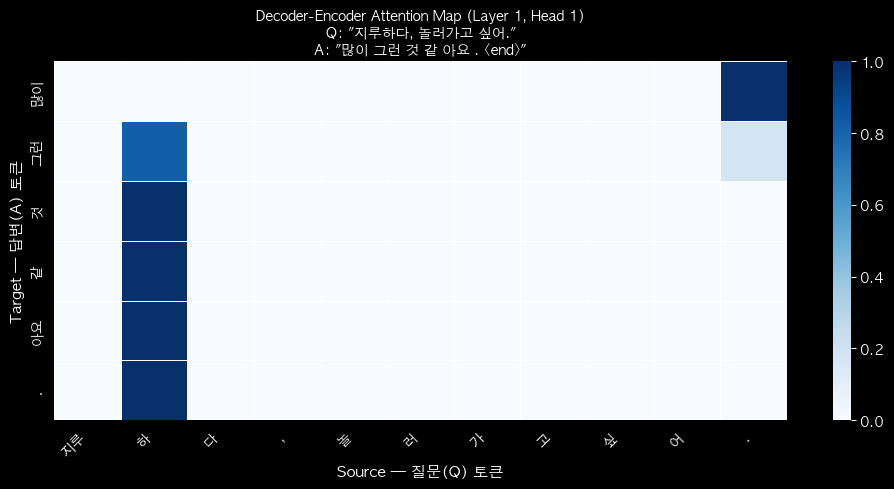

답변: 많이 그런 것 같 아요 . <end>

질문: 오늘 일찍 일어났더니 피곤하다.


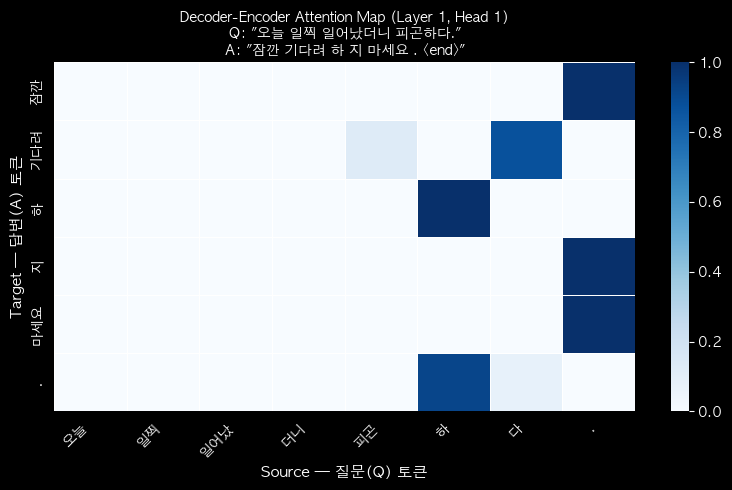

답변: 잠깐 기다려 하 지 마세요 . <end>
Sempre


In [28]:
# Cell 28

# ─── Attention Map 시각화 ────────────────────────────────────────
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False


def plot_attention_map(sentence, model, vocab, mecab, max_len, device,
                       layer=0, head=0):
    """
    Decoder-Encoder Cross-Attention 히트맵 시각화
    X축: 질문(Q) 형태소 토큰
    Y축: 생성된 답변(A) 형태소 토큰
    """
    result, src_tokens, tgt_tokens, dec_enc_attns = translate(
        sentence, model, vocab, mecab, max_len, device
    )
    if dec_enc_attns is None or not tgt_tokens:
        print('Attention을 시각화할 수 없습니다 (빈 응답).')
        return result

    # attn: [batch=1, n_heads, tgt_len, src_len]
    attn = dec_enc_attns[layer][0, head].cpu().numpy()

    n_src = min(len(src_tokens), attn.shape[1])
    n_tgt = min(len(tgt_tokens), attn.shape[0])
    attn  = attn[:n_tgt, :n_src]

    fig, ax = plt.subplots(figsize=(max(8, n_src * 0.9), max(5, n_tgt * 0.8)))
    sns.heatmap(
        attn,
        xticklabels=src_tokens[:n_src],
        yticklabels=tgt_tokens[:n_tgt],
        cmap='Blues', linewidths=0.5, vmin=0, vmax=1, ax=ax
    )
    ax.set_xlabel('Source — 질문(Q) 토큰', fontsize=11)
    ax.set_ylabel('Target — 답변(A) 토큰', fontsize=11)
    ax.set_title(
        f'Decoder-Encoder Attention Map (Layer {layer+1}, Head {head+1})\n'
        f'Q: "{sentence}"\nA: "{result}"', fontsize=10
    )
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'attn_L{layer+1}_H{head+1}.png', dpi=150)
    plt.show()
    return result


# 시각화 실행
for q in test_questions[:2]:
    print(f'\n질문: {q}')
    ans = plot_attention_map(q, transformer, vocab, mecab, MAX_LEN, device, layer=0, head=0)
    print(f'답변: {ans}')

print('Sempre')

In [29]:
# Cell 29

# ─── 챗봇 최종 테스트 ────────────────────────────────────────────
print('=' * 60)
print('           챗봇 최종 테스트')
print('=' * 60)

test_set = [
    ('지루하다, 놀러가고 싶어.',          '잠깐 쉬어도 돼요.'),
    ('오늘 일찍 일어났더니 피곤하다.',     '맛난 거 드세요.'),
    ('간만에 여자친구랑 데이트 하기로 했어.', '떨리겠죠.'),
    ('집에 있는다는 소리야.',             '좋아하면 그럴 수 있어요.'),
]

for q, expected in test_set:
    generated, _, cand_tokens, _ = translate(q, transformer, vocab, mecab, MAX_LEN, device)
    ref_tokens  = mecab.morphs(preprocess_sentence(expected))
    bleu = calculate_bleu(ref_tokens, cand_tokens)
    print(f'Q       : {q}')
    print(f'예상 답변: {expected}')
    print(f'생성 답변: {generated}')
    print(f'BLEU    : {bleu:.4f}')
    print('-' * 60)

print('Sempre')

           챗봇 최종 테스트
Q       : 지루하다, 놀러가고 싶어.
예상 답변: 잠깐 쉬어도 돼요.
생성 답변: 많이 그런 것 같 아요 . <end>
BLEU    : 0.0408
------------------------------------------------------------
Q       : 오늘 일찍 일어났더니 피곤하다.
예상 답변: 맛난 거 드세요.
생성 답변: 잠깐 기다려 하 지 마세요 . <end>
BLEU    : 0.0408
------------------------------------------------------------
Q       : 간만에 여자친구랑 데이트 하기로 했어.
예상 답변: 떨리겠죠.
생성 답변: 내 마세요 . <end>
BLEU    : 0.0814
------------------------------------------------------------
Q       : 집에 있는다는 소리야.
예상 답변: 좋아하면 그럴 수 있어요.
생성 답변: 많이 사랑 이 에요 . <end>
BLEU    : 0.0241
------------------------------------------------------------
Sempre


## 결과 요약

| 항목 | 내용 |
|------|------|
| 데이터 | ChatbotData.csv (한국어 Q&A) |
| 토크나이저 | **MeCab** (`python-mecab-ko`, `morphs()`) |
| 전처리 | `preprocess_sentence()` — 소문자 + 정규식 |
| 코퍼스 구축 | `build_corpus()` — 길이 필터 + 중복 제거 |
| Augmentation | 한국어 Word2Vec (`ko.bin`) Lexical Substitution, **3배** |
| 벡터화 | `<start>/<end>` + 공유 단어사전 → `enc_train`, `dec_train` |
| 모델 | Transformer (공유 임베딩 + 공유 FC) |
| 훈련 | Noam LR, Adam, `EPOCHS=10` |
| 평가 | BLEU-4 (smoothed) + Attention Map 시각화 |